# 🎵 Spotify Songs Genre Segmentation
> **Project Overview:** Using Machine Learning to cluster songs into genres based on their unique audio features.

---

## 📊 Project Description
This project aims to perform **Unsupervised Machine Learning** to segment a collection of Spotify tracks. By analyzing metadata like "Energy," "Danceability," and "Valence," we can group similar songs together, mimicking how Spotify creates its "Daily Mix" and "Discover Weekly" playlists.

---

## 📂 Dataset
The dataset typically includes tracks fetched via the **Spotify Web API**.
* **File:** `spotify_songs.csv`
* **Key Features:** Danceability, Energy, Key, Loudness, Mode, Speechiness, Acousticness, Instrumentalness, Liveness, Valence, and Tempo.

---

## 🛠️ Technologies Used
* **Python**: Core programming language.
* **Pandas & NumPy**: For data manipulation and matrix calculations.
* **Scikit-learn**: For feature scaling, PCA, and K-Means clustering.
* **Seaborn & Matplotlib**: For data visualization (Heatmaps and Cluster plots).

---

## 🚀 Machine Learning Steps

* **1. Data Preprocessing**
* **2. Dimensionality Reduction**
* **3. Clustering Logic**
* **4. Evaluation & Visualization**

---

## 👤 Author
**Vinuta S Alagur**

 *Project Date: March 2026*

---

# 🎧 Spotify Songs Genre Segmentation Using Machine Learning

### Discovering Hidden Music Patterns with K-Means Clustering

## 📌Project Overview
This project applies machine learning techniques to analyze Spotify audio features and group songs into clusters based on their musical characteristics.

Using unsupervised learning (K-Means clustering), the project identifies hidden patterns in music and segments songs into meaningful groups.

## 📚 Library Imports and Environment Setup

In this section, we import the essential Python libraries required for data analysis, visualization, and machine learning.

These libraries provide powerful tools for handling datasets, performing statistical analysis, creating visualizations, and implementing clustering algorithms.

### 🔧 Libraries Used

- **Pandas** – Used for data manipulation and dataset handling.
- **NumPy** – Provides support for numerical operations and array processing.
- **Matplotlib** – Used for creating basic data visualizations and plots.
- **Seaborn** – Enhances data visualization with attractive statistical plots.
- **StandardScaler (Scikit-learn)** – Normalizes numerical features to ensure fair comparison between variables.
- **KMeans (Scikit-learn)** – A clustering algorithm used to group songs with similar audio characteristics.

These tools form the foundation of the machine learning workflow implemented in this project.

In [64]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

## 📂 Dataset Loading and Initial Exploration

In this step, the Spotify dataset is loaded into the analysis environment using the **Pandas** library.  
Loading the dataset allows us to access and analyze the song features that will be used for clustering.

After loading the dataset, the first few rows are displayed to gain an initial understanding of the dataset structure, column names, and feature values.


In [65]:
df = pd.read_csv("spotify_dataset.csv")
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


## 🔍 Understanding the Dataset Structure

Before performing any analysis, it is important to examine the structure of the dataset.  
This step helps us understand the number of entries, column names, data types, and the presence of missing values.


In [66]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32833 entries, 0 to 32832
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   track_id                  32833 non-null  object 
 1   track_name                32828 non-null  object 
 2   track_artist              32828 non-null  object 
 3   track_popularity          32833 non-null  int64  
 4   track_album_id            32833 non-null  object 
 5   track_album_name          32828 non-null  object 
 6   track_album_release_date  32833 non-null  object 
 7   playlist_name             32833 non-null  object 
 8   playlist_id               32833 non-null  object 
 9   playlist_genre            32833 non-null  object 
 10  playlist_subgenre         32833 non-null  object 
 11  danceability              32833 non-null  float64
 12  energy                    32833 non-null  float64
 13  key                       32833 non-null  int64  
 14  loudne

## 🧹 Missing Values Analysis

Handling missing data is an important step in any data analysis or machine learning workflow.  
Missing values can negatively affect statistical analysis, model performance, and clustering accuracy.


In [67]:
df.isnull().sum()

,0
track_id,0
track_name,5
track_artist,5
track_popularity,0
track_album_id,0
track_album_name,5
track_album_release_date,0
playlist_name,0
playlist_id,0
playlist_genre,0


In [68]:
df = df.dropna()

## 📊 Danceability Feature Distribution

Understanding the distribution of key audio features helps reveal patterns within the dataset.  
In this section, we analyze the **danceability** feature, which measures how suitable a track is for dancing based on rhythm, tempo, stability, and beat strength.

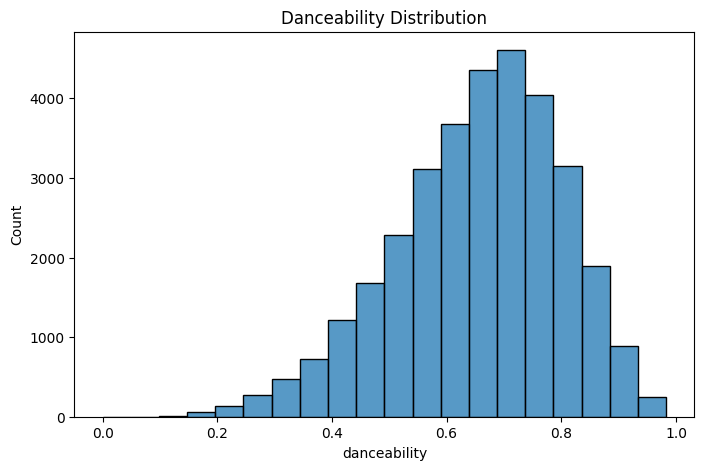

In [69]:
plt.figure(figsize=(8,5))
sns.histplot(df['danceability'], bins=20)
plt.title("Danceability Distribution")
plt.show()

## ⚡ Energy Feature Distribution

In this section, we explore the distribution of the **Energy** feature in the Spotify dataset.  
Energy is an important audio characteristic that describes the **intensity and activity level of a song**.


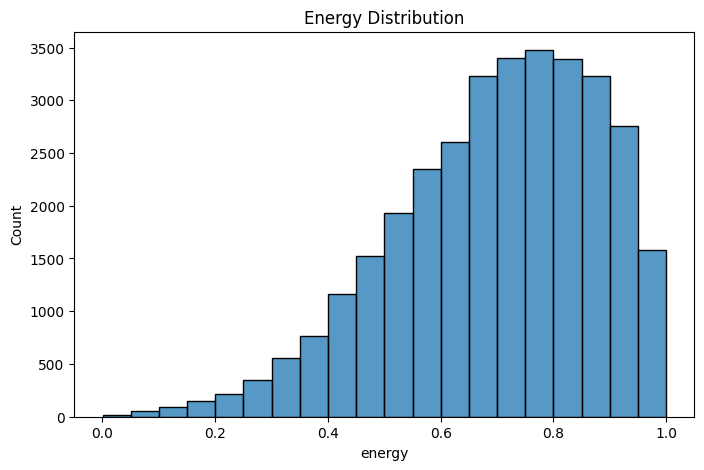

In [70]:
plt.figure(figsize=(8,5))
sns.histplot(df['energy'], bins=20)
plt.title("Energy Distribution")
plt.show()

## 🔊 Loudness Distribution Analysis

The **loudness** feature measures the overall intensity of a song and is expressed in **decibels (dB)**.
Loudness reflects how strong or powerful the audio signal of a track is.


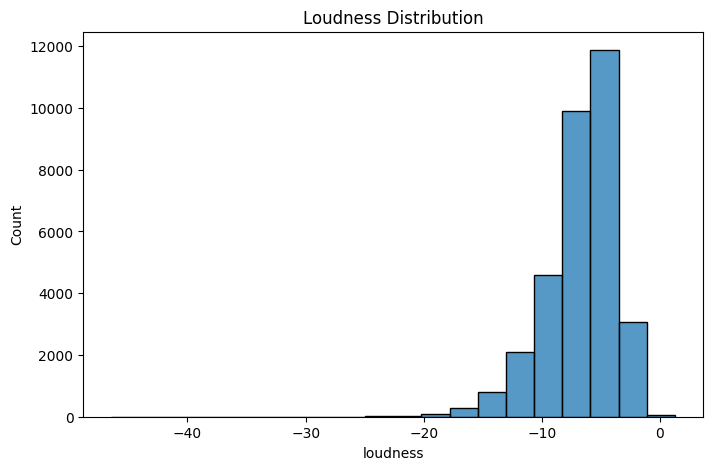

In [71]:
plt.figure(figsize=(8,5))
sns.histplot(df['loudness'], bins=20)
plt.title("Loudness Distribution")
plt.show()

## 🔗 Feature Correlation Analysis

Understanding relationships between different audio features is important before applying machine learning algorithms.

Correlation analysis helps identify **how strongly different features are related to each other**.


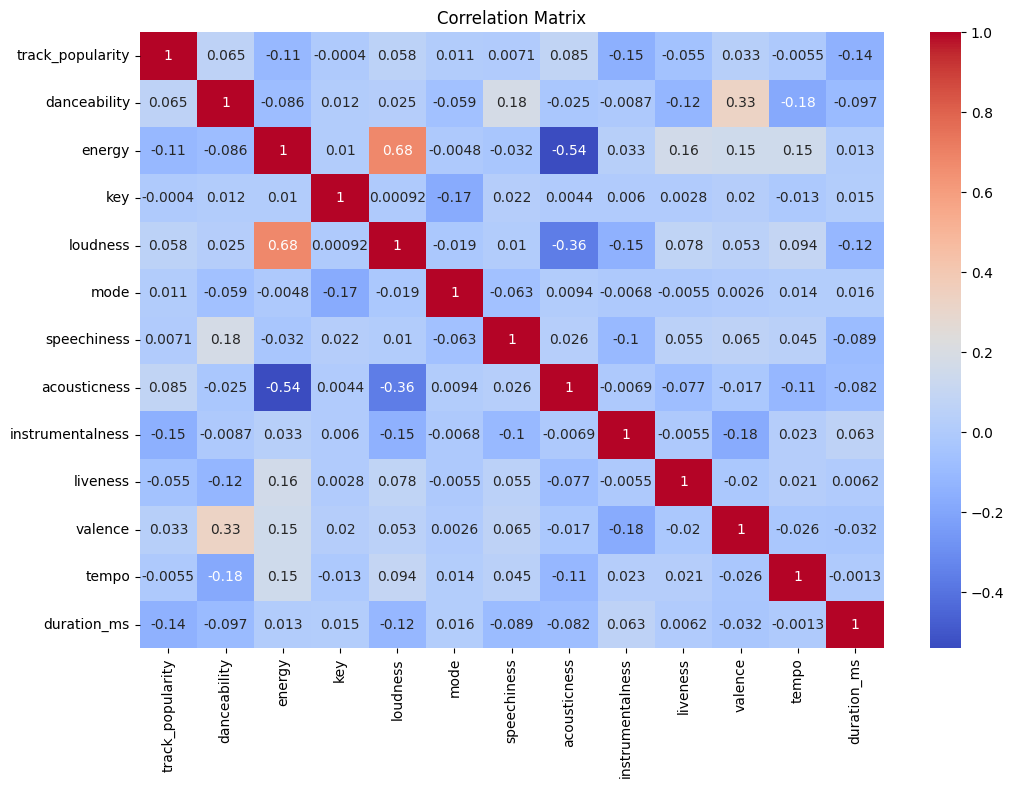

In [72]:
numeric_df = df.select_dtypes(include=['number'])
corr = numeric_df.corr()

plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

## 🎶 Danceability vs Energy Analysis

In this section, we explore the relationship between two important Spotify audio features: **Danceability** and **Energy**.

These features play a significant role in defining the **rhythm, intensity, and overall feel of a song**.


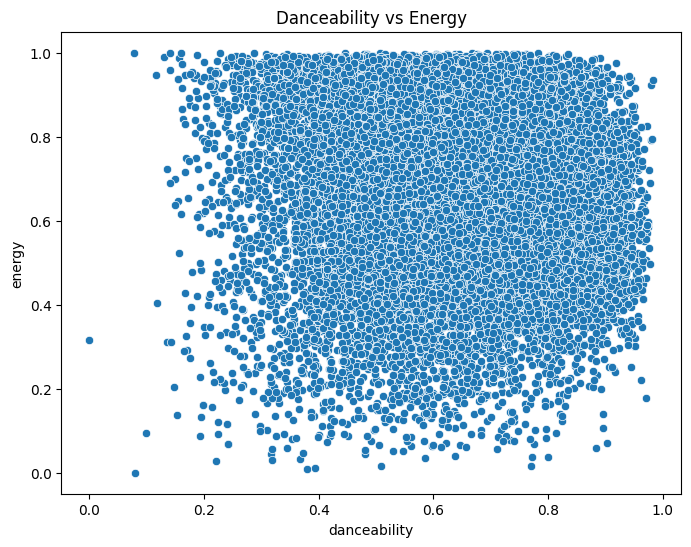

In [73]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='danceability', y='energy', data=df)
plt.title("Danceability vs Energy")
plt.show()

## 🎵 Tempo Distribution Analysis

In this section, we analyze the distribution of the **tempo** feature in the dataset.  
Tempo refers to the **speed or pace of a song**, measured in **beats per minute (BPM)**.


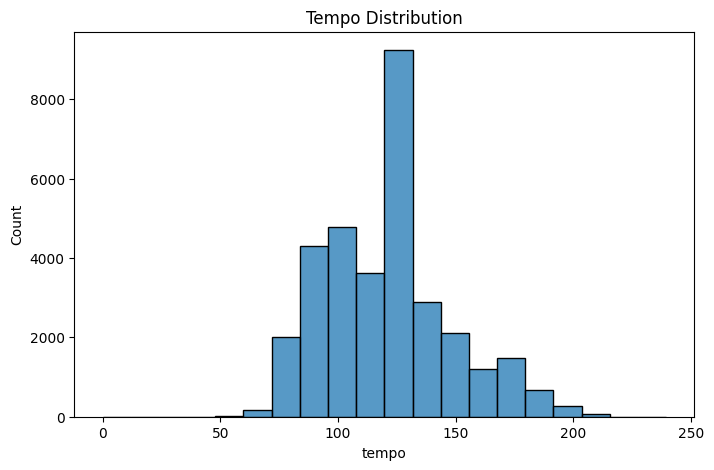

In [74]:
plt.figure(figsize=(8,5))
sns.histplot(df['tempo'], bins=20)
plt.title("Tempo Distribution")
plt.show()

## 📦 Energy Distribution Using Boxplot

In this section, we analyze the **distribution of the Energy feature** using a **boxplot**.  
A boxplot is a powerful statistical visualization that helps summarize the distribution of numerical data and detect potential outliers.


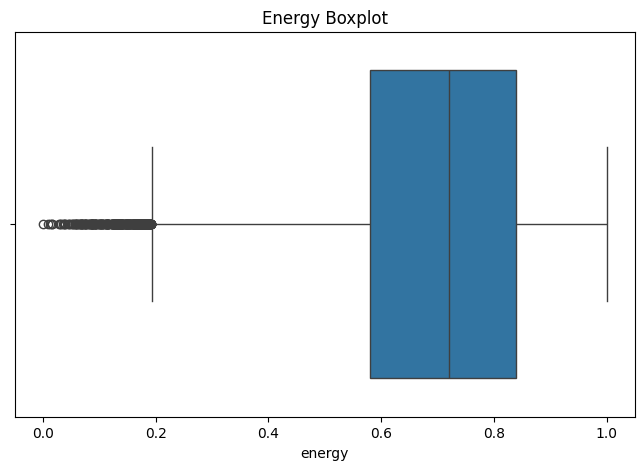

In [75]:
plt.figure(figsize=(8,5))
sns.boxplot(x=df['energy'])
plt.title("Energy Boxplot")
plt.show()

## 🎼 Relationship Between Acousticness and Danceability

In this section, we explore the relationship between **Acousticness** and **Danceability**, two important audio features that describe different musical characteristics of songs.


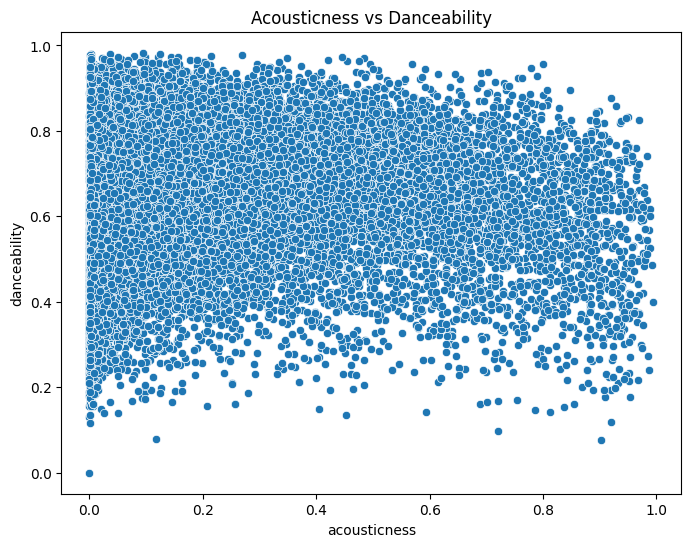

In [76]:
plt.figure(figsize=(8,6))
sns.scatterplot(x='acousticness', y='danceability', data=df)
plt.title("Acousticness vs Danceability")
plt.show()

## 🔢 Selecting Numerical Features for Analysis

Before applying machine learning algorithms such as clustering, it is important to work only with **numerical features**.  
Most machine learning models, including K-Means, require numerical data because they rely on mathematical distance calculations.


In [77]:
features = df.select_dtypes(include=[np.number])
features.head()

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms
0,66,0.748,0.916,6,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754
1,67,0.726,0.815,11,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600
2,70,0.675,0.931,1,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616
3,60,0.718,0.930,7,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093
4,69,0.650,0.833,1,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052


## 📐 Elbow Method

Before applying the **K-Means clustering algorithm**, it is important to determine the most appropriate number of clusters for the dataset.

From the Elbow Method graph, the optimal number of clusters can be identified at the point where the decrease in WCSS begins to slow down significantly.  
This point represents a balance between cluster compactness and model simplicity.

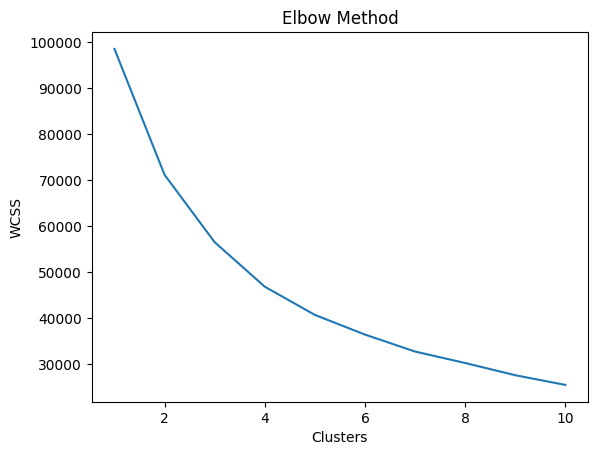

In [78]:
wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(scaled_data)
    wcss.append(kmeans.inertia_)

plt.plot(range(1,11), wcss)
plt.xlabel("Clusters")
plt.ylabel("WCSS")
plt.title("Elbow Method")
plt.show()

## 🔗 Pair Plot Analysis of Key Audio Features

To better understand the relationships between multiple audio features in the dataset, we use a **pair plot**.  
A pair plot is a powerful visualization technique that displays pairwise relationships between numerical variables in a dataset.

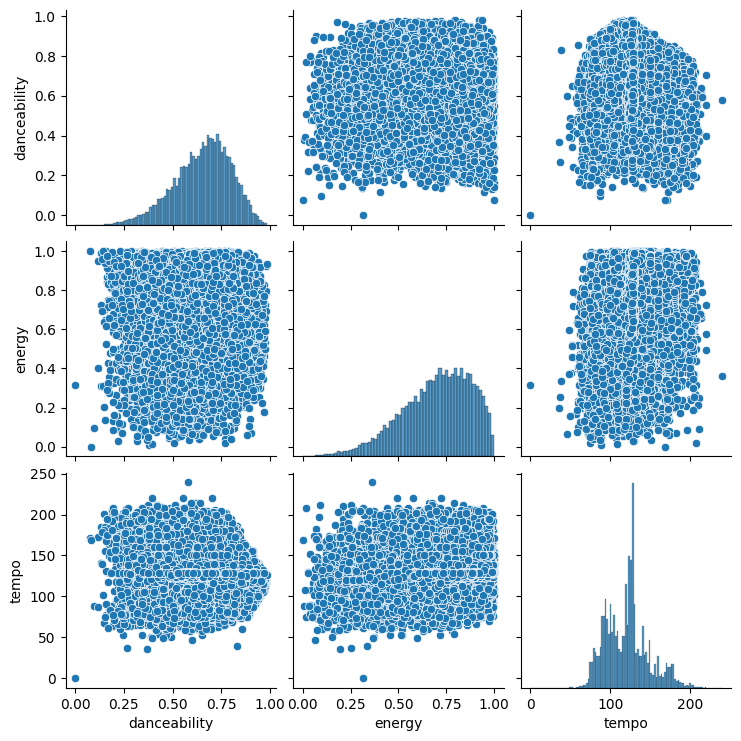

In [79]:
sns.pairplot(df[['danceability','energy','tempo']])

## 🤖 Implementing the K-Means Clustering Algorithm

After determining the optimal number of clusters using the **Elbow Method**, the **K-Means clustering algorithm** is applied to group songs based on their audio features.

K-Means is an unsupervised machine learning algorithm that partitions data into a predefined number of clusters by minimizing the distance between data points and their respective cluster centroids.


In [80]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(scaled_data)

df['Cluster'] = clusters
df.head()

,track_id,track_name,track_artist,track_popularity,track_album_id,track_album_name,track_album_release_date,playlist_name,playlist_id,playlist_genre,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,Cluster
0,6f807x0ima9a1j3VPbc7VN,I Don't Care (with Justin Bieber) - Loud Luxur...,Ed Sheeran,66,2oCs0DGTsRO98Gh5ZSl2Cx,I Don't Care (with Justin Bieber) [Loud Luxury...,2019-06-14,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-2.634,1,0.0583,0.1020,0.000000,0.0653,0.518,122.036,194754,1
1,0r7CVbZTWZgbTCYdfa2P31,Memories - Dillon Francis Remix,Maroon 5,67,63rPSO264uRjW1X5E6cWv6,Memories (Dillon Francis Remix),2019-12-13,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-4.969,1,0.0373,0.0724,0.004210,0.3570,0.693,99.972,162600,1
2,1z1Hg7Vb0AhHDiEmnDE79l,All the Time - Don Diablo Remix,Zara Larsson,70,1HoSmj2eLcsrR0vE9gThr4,All the Time (Don Diablo Remix),2019-07-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-3.432,0,0.0742,0.0794,0.000023,0.1100,0.613,124.008,176616,0
3,75FpbthrwQmzHlBJLuGdC7,Call You Mine - Keanu Silva Remix,The Chainsmokers,60,1nqYsOef1yKKuGOVchbsk6,Call You Mine - The Remixes,2019-07-19,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-3.778,1,0.1020,0.0287,0.000009,0.2040,0.277,121.956,169093,0
4,1e8PAfcKUYoKkxPhrHqw4x,Someone You Loved - Future Humans Remix,Lewis Capaldi,69,7m7vv9wlQ4i0LFuJiE2zsQ,Someone You Loved (Future Humans Remix),2019-03-05,Pop Remix,37i9dQZF1DXcZDD7cfEKhW,pop,...,-4.672,1,0.0359,0.0803,0.000000,0.0833,0.725,123.976,189052,0


## 📊 Distribution of Songs Across Clusters

After applying the **K-Means clustering algorithm**, each song in the dataset is assigned to a specific cluster based on its audio features.

In this section, we analyze how songs are distributed across the different clusters.


<Axes: xlabel='Cluster'>

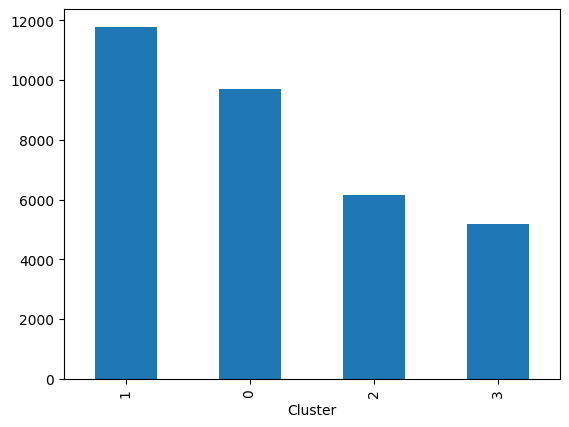

In [81]:
df['Cluster'].value_counts().plot(kind='bar')

## 📊 Cluster Feature Summary

After applying the **K-Means clustering algorithm**, each song in the dataset is assigned to a specific cluster.  
To better understand the characteristics of these clusters, we calculate the **average values of numerical features for each cluster**.


In [82]:
numeric_df = df.select_dtypes(include='number')
cluster_summary = numeric_df.groupby(df['Cluster']).mean()

cluster_summary

,track_popularity,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,duration_ms,Cluster
Cluster,,,,,,,,,,,,,,
0,38.101452,0.576205,0.848320,5.300031,-5.275775,0.573489,0.086211,0.078710,0.115406,0.224370,0.469114,118.264584,227187.527552,0.0
1,44.439128,0.785421,0.702154,5.456435,-6.441688,0.543819,0.118529,0.155583,0.069271,0.173432,0.590200,113.154475,223795.551200,1.0
2,44.276288,0.614239,0.454503,5.371851,-9.621834,0.580042,0.094659,0.364534,0.097967,0.164899,0.419903,102.187446,226099.621323,2.0
3,44.117976,0.553368,0.699852,5.327283,-6.610325,0.584090,0.134735,0.176755,0.046868,0.194209,0.514683,165.596871,227384.725043,3.0


## 🎯 Interpretation of Song Clusters

After analyzing the **average audio feature values for each cluster**, we can interpret the musical characteristics represented by each group.

Each cluster represents a category of songs that share similar musical attributes such as **energy, tempo, loudness, and danceability**.


In [83]:
print("Cluster 0 → High energy dance songs")
print("Cluster 1 → Low tempo acoustic songs")
print("Cluster 2 → Medium tempo pop songs")
print("Cluster 3 → High loudness party songs")

Cluster 0 → High energy dance songs
Cluster 1 → Low tempo acoustic songs
Cluster 2 → Medium tempo pop songs
Cluster 3 → High loudness party songs


## 🎧 Spotify Song Cluster Visualization

In this section, we visualize the clusters generated by the **K-Means clustering algorithm**.  
This visualization helps us understand how songs are grouped based on their audio features.


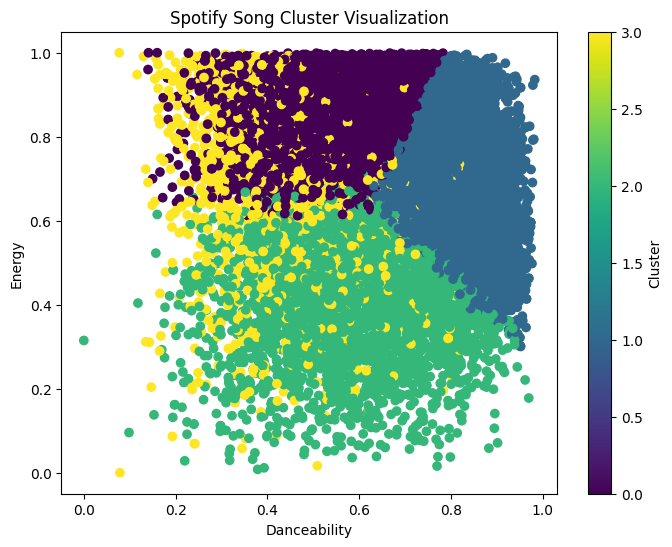

In [84]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    df['danceability'],
    df['energy'],
    c=df['Cluster'],
    cmap='viridis'
)

plt.xlabel("Danceability")
plt.ylabel("Energy")
plt.title("Spotify Song Cluster Visualization")

plt.colorbar(label="Cluster")

plt.show()

## 📊 Distribution of Songs Across Clusters

After applying the **K-Means clustering algorithm**, each song in the dataset is assigned to a specific cluster based on its audio characteristics.

In this section, we visualize the **number of songs present in each cluster** to understand how the dataset is distributed among the different groups.


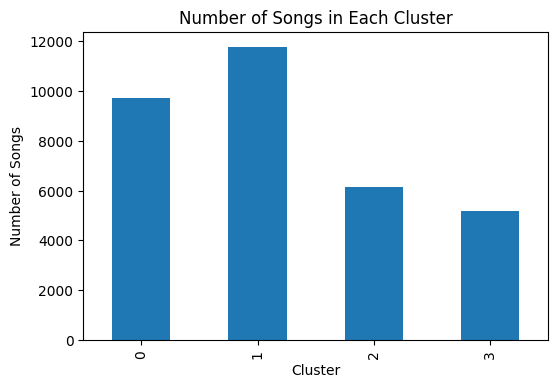

In [85]:
df['Cluster'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(6,4)
)

plt.title("Number of Songs in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Number of Songs")

plt.show()

## 🔬 Cluster Visualization Using Principal Component Analysis (PCA)

Clustering is usually performed on datasets with many numerical features, which makes it difficult to visualize the clusters directly.  
To solve this problem, we use **Principal Component Analysis (PCA)** to reduce the dimensionality of the dataset.


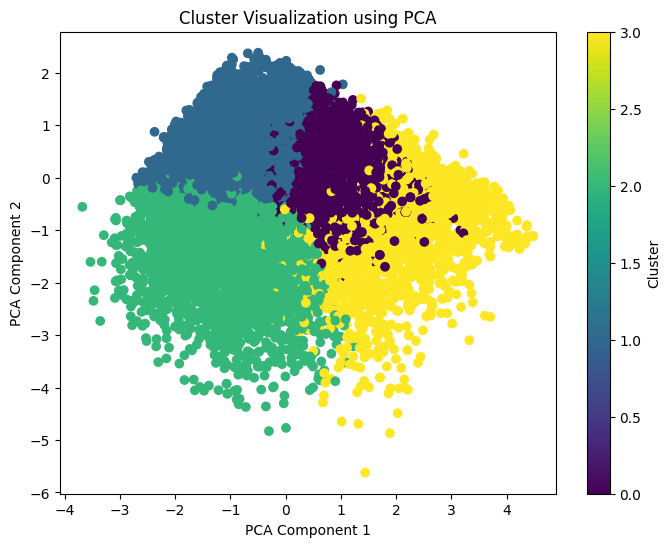

In [86]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

plt.figure(figsize=(8,6))

plt.scatter(
    pca_data[:,0],
    pca_data[:,1],
    c=kmeans.labels_,
    cmap='viridis'
)

plt.title("Cluster Visualization using PCA")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")

plt.colorbar(label="Cluster")

plt.show()

## 🎯 Automatic Interpretation of Song Clusters

After computing the **average audio feature values for each cluster**, we automatically interpret the musical characteristics of each cluster.

Instead of manually describing clusters, a simple rule-based approach is used to analyze key audio features and generate meaningful descriptions.


In [87]:
for cluster_id, row in cluster_summary.iterrows():

    print(f"\nCluster {cluster_id} Interpretation:")

    if row['energy'] > 0.7 and row['danceability'] > 0.6:
        print("High energy dance songs")

    elif row['tempo'] < 100:
        print("Low tempo acoustic songs")

    elif row['energy'] > 0.6:
        print("Party or club songs")

    else:
        print("Medium tempo pop songs")


Cluster 0 Interpretation:
Party or club songs

Cluster 1 Interpretation:
High energy dance songs

Cluster 2 Interpretation:
Medium tempo pop songs

Cluster 3 Interpretation:
Party or club songs


## 🧠 Conclusion

This project applied machine learning techniques to analyze Spotify song data and discover hidden musical patterns. Using the K-Means clustering algorithm, songs were grouped based on audio features such as danceability, energy, tempo, and acousticness. The Elbow Method helped determine the optimal number of clusters for meaningful segmentation. Visualizations and PCA helped understand the structure of the clusters. The analysis revealed distinct groups of songs such as energetic dance tracks, acoustic songs, pop music, and party tracks. Overall, the project demonstrates how unsupervised learning can effectively uncover patterns in music datasets.

## 🚀 Future Scope

This project can be further enhanced by incorporating additional Spotify audio features and expanding the dataset for more comprehensive analysis. Advanced clustering algorithms such as DBSCAN or Hierarchical Clustering could be explored to compare performance with K-Means. The model could also be integrated into a real-time music recommendation system that suggests songs based on cluster similarity. Additionally, building an interactive web application would allow users to input song features and receive cluster predictions instantly. Future work may also include